# Silicon Calculation

The purpose of this notebook is to demonstrate a calculation of a graphene system and the extraction of the real-space Hamiltonian.

## Imports

In [1]:
from ase import Atoms
from ase.calculators.openmx import OpenMX
from kodiak_openmx import OpenMXScfout, run_openmx, read_openmx_band, get_job_status

import os
from pathlib import Path
# import pbs_tools as pbs
import numpy as np

## Filespace Parameters

In [2]:
prefix = 'silicon'

homedir = os.getcwd()

# calcs is the symlink to a storage directory you prepared
# Each OpenMX calculation should have its own workdir. Input and output files will be stored here
workdir = os.path.join( '..', '..', 'calcs', 'examples',
                      prefix)

Path( workdir ).mkdir( exist_ok=True, parents=True )

os.path.exists( workdir )
print(workdir)

../../calcs/examples/silicon


## Define the Periodic System

In [3]:
from ase.build import bulk

a = 5.43

positions = [
    [0.0, 0.0, 0.0],
    [0.0, a/np.sqrt(3), 0.0]
]


# Silicon diamond structure
atoms = bulk(
    "Si",
    crystalstructure="diamond",
    a = a  # Angstrom
)

# Ensure periodicity
atoms.pbc = [True, True, True]

definition_of_atomic_species = [
    ['Si', 'Si7.0-s2p2d1', 'Si_PBE19']
]

print(f'Initial path: {homedir}')

Initial path: /ion/home/blaire/Research/kodiak-openmx/notebooks/examples


In [4]:
scf_kgrid = (8, 8, 8)

In [5]:
band_nkpath = 5

band_kpath = [
    [60, 0.0, 0.0, 0.0,  0.5, 0.0, 0.5,  "G", "X"],
    [60, 0.5, 0.0, 0.5,  0.5, 0.25, 0.75, "X", "W"],
    [60, 0.5, 0.25, 0.75, 0.375, 0.375, 0.75, "W", "K"],
    [60, 0.375, 0.375, 0.75, 0.0, 0.0, 0.0, "K", "G"],
    [60, 0.0, 0.0, 0.0,  0.5, 0.5, 0.5, "G", "L"],
]

## Prepare an `OpenMX` Input File

In [6]:
# omx_command isn't actually used to run the calculation
# This is needed so we don't get an ASE error about a missing configuration
#   for OpenMX
omx_command = f'command="openmx {prefix}.dat > {prefix}.out",'

calc = OpenMX(
    data_path='/usr/local/apps/openmx/3.9/DFT_DATA19',
    directory=workdir,
    system_currentdirectory='./',
    command=omx_command,
    label=prefix,

    definition_of_atomic_species=definition_of_atomic_species,

    scf_kgrid = scf_kgrid,
    scf_xctype='GGA-PBE',
    scf_spinpolarization='off',

    scf_eigenvaluesolver='dc',
    scf_maxiter=100,
    scf_energycutoff=150,

    hs_fileout=True,

    band_dispersion=True,
    band_nkpath=band_nkpath,
    band_kpath=band_kpath,
)

# Associate the calculator with the atoms object
atoms.calc = calc

# We do not use atoms.get_potential_energy() to run OpenMX, but rather,
#   we use some custom code in the kodiak_openmx package (not this
#   cell)
# energy = atoms.get_potential_energy()

# Write the OpenMX input file
calc.write_input(atoms)

In [7]:
! pwd
! ls ../../calcs/examples/silicon

/ion/home/blaire/Research/kodiak-openmx/notebooks/examples
outputFile.std	  silicon.dat	     silicon.md        silicon.scfout
scf_status.txt	  silicon.dat#	     silicon.md2       silicon.tden.cube
silicon.Band	  silicon.dden.cube  silicon.o3998119  silicon.v0.cube
silicon.bulk.xyz  silicon.e3998119   silicon.out       silicon.vhart.cube
silicon.cif	  silicon.ene	     silicon_rst       silicon.xyz


## Run `OpenMX`

`run_openmx()` launches a calculation on Kodiak via PBS. It's designed to refrain from launching a calculation if:
1. a previous execution of the following cell already has queued a job,
2. that job is in progress, or
3. the previously-launched job is complete.

`run_openmx()` can track the status of a previously-queued job because we create a status (`statusFile.txt`) that indicate when a job is queued, started, and ended.

If you need to re-run `OpenMX`, delete the status file, or delete the entire work directory.

In [8]:
# Run OpenMX
run_openmx( prefix, workdir, verbose=True )

has_status = os.path.exists( os.path.join( workdir,
                                           'scf_status.txt' )
                            )

print(f'Found status file: {has_status}')

Job ID: 3998119
Status file detected. Calculation skipped.
Found status file: True


## Post-processing

The following code checks to see whether the job is done. If the job is not done, we do not go on to the post-processing.

In [9]:

if has_status:
    job_status = get_job_status( os.path.join( workdir,
                                               'scf_status.txt'),
                                 os.path.join( workdir,
                                               'outputFile.std') )
    print(f'Job status: {job_status}')
else:
    print('The job does not yet have a status file. Try running the above code blocks to launch the calculation.')

# Prevent post-processing if the job is not done
assert job_status == 'done', "Job is not yet done. We will avoid post-processing."

# Parse the Hamiltonian
scf = OpenMXScfout( os.path.join( workdir,
                                  f'{prefix}.scfout') )


Job status: done


Next, we may wish to inspect some of the results contained within the `scf` object:

In [10]:
# print the real-space Hamiltonian (it's a sparse matrix)
print(scf.H_R) 

print("atomnum =", scf.atomnum)
print("Total_NumOrbs =", scf.Total_NumOrbs)
print("nbasis =", scf.nbasis)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 676 stored elements and shape (26, 26)>
  Coords	Values
  (0, 0)	-0.7188335008270769
  (0, 1)	0.7111081527167
  (0, 2)	3.765980611867954e-06
  (0, 3)	3.7659883530464746e-06
  (0, 4)	3.765988799037585e-06
  (0, 5)	-1.368961490589432e-05
  (0, 6)	-1.3689627526208848e-05
  (0, 7)	-1.3689626957250327e-05
  (0, 8)	1.9924220086287026e-10
  (0, 9)	2.711713798967068e-15
  (0, 10)	2.4320920018681546e-05
  (0, 11)	2.4320919047308306e-05
  (0, 12)	2.432091719562282e-05
  (0, 13)	-0.7258142827919322
  (0, 14)	0.6982806042760142
  (0, 15)	-7.696164335322438e-06
  (0, 16)	-7.6961637008547e-06
  (0, 17)	-7.696164150347573e-06
  (0, 18)	8.871157583072165e-06
  (0, 19)	8.871152836938123e-06
  (0, 20)	8.87115232468122e-06
  (0, 21)	5.7587290377926134e-11
  (0, 22)	9.261797058457422e-16
  (0, 23)	1.9475864514052338e-05
  (0, 24)	1.947586376764652e-05
  :	:
  (25, 1)	-5.8528176967189566e-05
  (25, 2)	-0.09253895751741213
  (25, 3)	3.80384869320

## Validation

We would like to validate the results to some extent.

### Is the Hamiltonian Hermitian?

In [11]:
# Convert sparse matrix to dense matrix
H = scf.H_R.toarray()

# Compute Hermiticity error
herm_diff = H - H.conj().T

# This is messy, but print it if you wish
# print("\nH - H†:")
# print(herm_diff)

# Maximum absolute deviation from Hermiticity
max_error = np.max(np.abs(herm_diff))

print(f"\nMaximum Hermiticity error: {max_error:e}")

# Boolean check
is_hermitian = np.allclose(H, H.conj().T)

print(f"Hermitian? {is_hermitian}")


Maximum Hermiticity error: 1.059212e-10
Hermitian? True


### Eigenvalues

In [12]:
from scipy.linalg import eigh

H = scf.H_R.toarray() # real-space Hamiltonain
S = scf.S_R.toarray() # real-space overlap matrix

# Solve the generalized eigenvalue problem
eigvals, eigvecs = eigh(H, S)

print("Eigenvalues (Hartree):")
print(eigvals)

print("Eigenvalues (eV):")
print(eigvals * 27.2114)

print("\n" + "="*20 + "\nFor a periodic system:\n")
for n in range(20):
    print(
        scf.H_R_rows[n],
        scf.H_R_cols[n],
        scf.H_R_cell_indices[n],
        scf.H_R_data[n]
    )

Eigenvalues (Hartree):
[-0.55485898 -0.11568635 -0.11568635 -0.1156659  -0.01946303 -0.01946303
 -0.01944697  0.03055338  0.17736088  0.17736088  0.3141028   0.42718429
  0.4272629   0.4272629   0.79163418  0.79163419  0.88397915  0.88397915
  0.8840492   1.17477566  1.17504445  1.17504446  1.73831516  1.73831518
  1.73849328  2.22022032]
Eigenvalues (eV):
[-15.09848954  -3.1479875   -3.1479875   -3.14743119  -0.52961635
  -0.52961635  -0.52917923   0.83140027   4.82623773   4.82623781
   8.5471768   11.62428251  11.62642178  11.62642179  21.54147437
  21.5414746   24.05431021  24.05431021  24.05621627  31.96729034
  31.97460458  31.97460489  47.30198927  47.30198957  47.30683607
  60.41530334]

For a periodic system:

0 0 0 -0.41693251211984284
0 1 0 0.07189610078149643
0 2 0 1.1192667279325978e-08
0 3 0 1.1199169903076192e-08
0 4 0 1.1199666873609346e-08
0 5 0 -1.0363149024296411e-05
0 6 0 -1.036315935851876e-05
0 7 0 -1.0363159115098117e-05
0 8 0 2.1091764063059578e-10
0 9 0 3.70654

### Band Structure Validation

In [17]:
#
# Reciprocal lattice vectors
#
B = scf.reciprocal_vectors()

#
# High-symmetry points in fractional coordinates
#
Gamma = np.array([0.0, 0.0, 0.0])
X     = np.array([0.5, 0.0, 0.5])
W     = np.array([0.5, 0.25, 0.75])
K     = np.array([0.375, 0.375, 0.75])
L     = np.array([0.5, 0.5, 0.5])

#
# Path segments
#
path = [
    (Gamma, X, 60),
    (X, W, 60),
    (W, K, 60),
    (K, Gamma, 60),
    (Gamma, L, 60),
]

kdist = []

bands = []

cumulative_distance = 0.0

prev_kcart = None

for iseg, (kstart, kend, nk_segment) in enumerate(path):

    for t in np.linspace(
            0.0,
            1.0,
            nk_segment
    ):

        #
        # Fractional k-point
        #
        kfrac = (
            (1.0 - t) * kstart
            + t * kend
        )

        #
        # Cartesian k-point
        #
        kcart = (
            kfrac[0] * B[0]
            + kfrac[1] * B[1]
            + kfrac[2] * B[2]
        )

        #
        # Build cumulative path distance
        #
        if prev_kcart is not None:

            cumulative_distance += np.linalg.norm(
                kcart - prev_kcart
            )

        kdist.append(cumulative_distance)

        #
        # Bloch Hamiltonian
        #
        Hk = scf.Hk(kcart)

        Sk = scf.Sk(kcart)

        eigvals, eigvecs = eigh(Hk, Sk)

        bands.append(eigvals.real)

        prev_kcart = kcart.copy()

bands = np.array(bands)

kdist = np.array(kdist)

# The file containing band structure data ends in *.Band
bands_data = os.path.join( workdir, f'{prefix}.Band')

# Parse the OpenMX band structure results
k_openmx, bands_openmx, Ef_openmx = read_openmx_band(
    bands_data,
    B
)

# Align parser data to the Fermi level
bands = bands * 27.2114 - Ef_openmx

# Normalize the kpoints so that OpenMX bands can be plotted against
#   those based on the real-space H and S matrices
x_parser = kdist / np.max(kdist)
x_openmx = k_openmx / np.max(k_openmx)

# This is an offset I chose after the fact to make the reference data (OpenMX band structure)
# align vertically with that which we obtain from H_R and S_R
E_offset = -1.5 # [eV] A manual vertical offset to compare the bands

print(f'Fermi energy from OpenMX: {Ef_openmx}')


Fermi energy from OpenMX: -1.5629828342111487


#### Visualize the Band structure

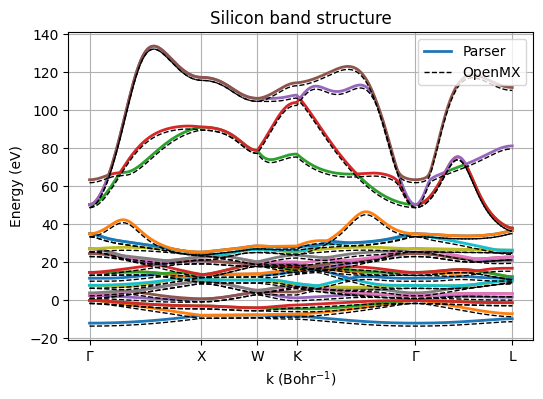

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

for n in range(bands.shape[1]):

    plt.plot(
        x_parser,
        bands[:, n] - E_offset,
        linewidth=2,
        label="Parser" if n == 0 else None
    )

#
# OpenMX reference bands
#
for n in range(bands_openmx.shape[1]):
    plt.plot(
        x_openmx,
        bands_openmx[:, n] - E_offset,
        "k--",
        linewidth=1,
        label="OpenMX" if n == 0 else None
    )

plt.xlabel("k (Bohr$^{-1}$)")
plt.ylabel("Energy (eV)")
plt.title("Silicon band structure")

tick_positions = [
    0.0,
    kdist[60-1],
    kdist[120-1],
    kdist[180-1],
    kdist[240-1],
    kdist[-1]
]

tick_positions = np.array(tick_positions)
tick_positions /= np.max(kdist)

plt.xticks(
    tick_positions,
    [r"$\Gamma$", "X", "W", "K", r"$\Gamma$", "L"]
)

plt.legend()

plt.grid(True)

plt.show()


#### A zoomed-in Band Structure Plot

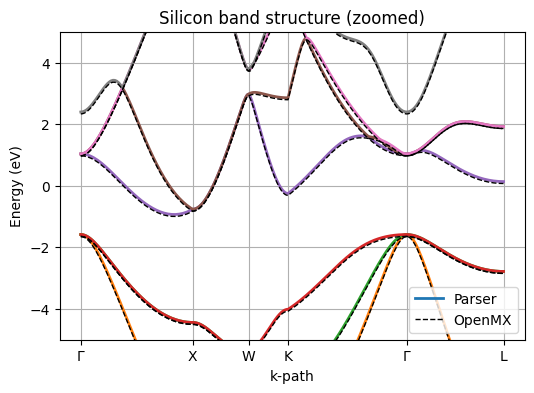

In [19]:
plt.figure(figsize=(6,4))

for n in range(bands.shape[1]):

    plt.plot(
        x_parser,
        bands[:, n],
        linewidth=2,
        label="Parser" if n == 0 else None
    )

for n in range(bands_openmx.shape[1]):

    plt.plot(
        x_openmx,
        bands_openmx[:, n] - E_offset,
        "k--",
        linewidth=1,
        label="OpenMX" if n == 0 else None
    )

plt.xticks(
    tick_positions,
    [r"$\Gamma$", "X", "W", "K", r"$\Gamma$", "L"]
)

plt.ylim(-5, 5)

plt.xlabel("k-path")
plt.ylabel("Energy (eV)")

plt.title("Silicon band structure (zoomed)")

plt.grid(True)

plt.legend()

plt.show()

This indirect band structure is what we would expect, so we think we have a nice validation of the real-space Hamiltonian.